In [1]:
"""This Notebook requires the .npy files that contains the distances of the object to the camera. 
To generate these .npy files use the statistics.py to calculate these values for the current dataset. 
"""

import os
import sys

import matplotlib.ticker as ticker
import numpy as np

sys.path.append(os.path.abspath("../"))

from pathlib import Path

import matplotlib.pyplot as plt

In [2]:
path_to_distances = Path("..", "..", "data", "distances")

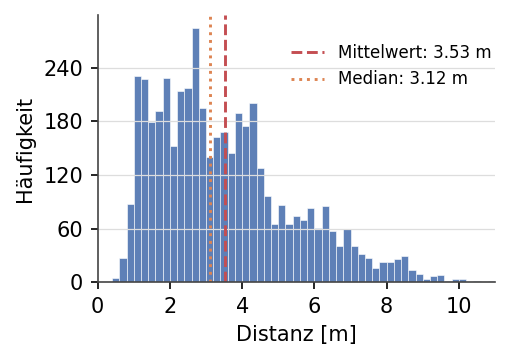

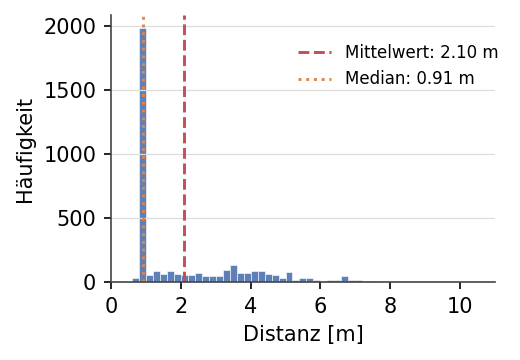

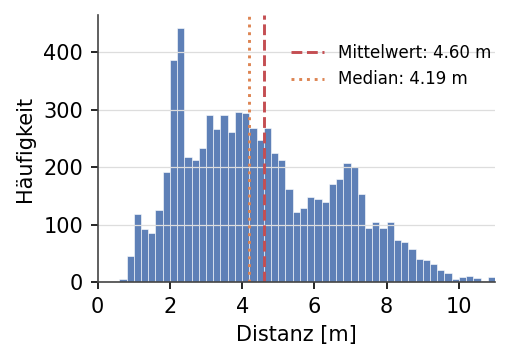

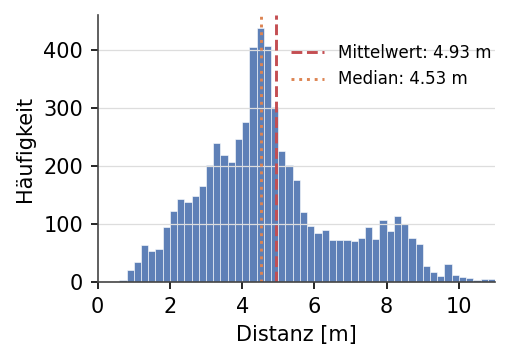

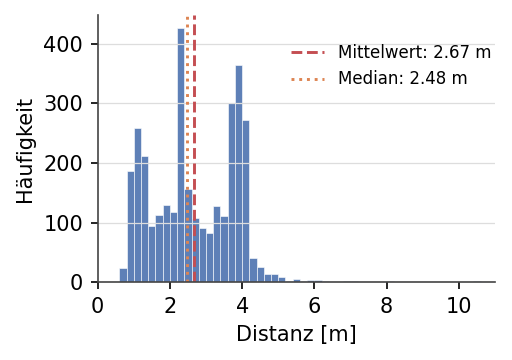

In [3]:
# --------------------------------------------------------------
# Stil-Konfiguration
# --------------------------------------------------------------
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica Neue", "Arial", "DejaVu Sans"],
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "axes.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "#444444",
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "grid.color": "#dddddd",
        "grid.linewidth": 0.6,
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
    }
)

BAR_COLOR = "#4C72B0"
MEAN_COLOR = "#C44E52"
MEDIAN_COLOR = "#DD8452"

# --------------------------------------------------------------
# Daten laden
# --------------------------------------------------------------

data = {
    "ball": ("Ball", np.load(Path(path_to_distances, "ball.npy"))),
    "penalty_mark": ("Elfmeterpunkt", np.load(Path(path_to_distances, "penaltyMark.npy"))),
    "l_intersection": ("L-Kreuzung", np.load(Path(path_to_distances, "l_intersection.npy"))),
    "t_intersection": ("T-Kreuzung", np.load(Path(path_to_distances, "t_intersection.npy"))),
    "x_intersection": ("X-Kreuzung", np.load(Path(path_to_distances, "x_intersection.npy"))),
}

bin_edges = np.arange(0, 9 + 2, 0.1)
x_max = 11

# --------------------------------------------------------------
# Ein Plot pro Kategorie
# --------------------------------------------------------------
# x_max = np.ceil(max(np.max(v) for _, v in data.values()) / 2) * 2
for filename, (title, values) in data.items():
    fig, ax = plt.subplots(figsize=(3.5, 2.5))  # schmaler und kompakter

    # x_max = np.ceil(np.max(values) / 2) * 2  # aufrunden auf nächste gerade Zahl

    bin_edges = np.arange(0, x_max + 0.1, 0.2)

    counts, edges = np.histogram(values, bins=bin_edges)
    ax.bar(
        edges[:-1],
        counts,
        width=np.diff(edges),
        color=BAR_COLOR,
        edgecolor="white",
        linewidth=0.3,
        alpha=0.9,
        align="edge",
    )

    mean = np.mean(values)
    median = np.median(values)

    ax.axvline(
        mean, color=MEAN_COLOR, linewidth=1.4, linestyle="--", label=f"Mittelwert: {mean:.2f} m"
    )
    ax.axvline(
        median, color=MEDIAN_COLOR, linewidth=1.4, linestyle=":", label=f"Median: {median:.2f} m"
    )

    # ax.set_title(title)
    ax.set_xlabel("Distanz [m]")
    ax.set_ylabel("Häufigkeit")
    ax.set_xlim(0, x_max)
    ax.set_xticks(np.arange(0, x_max + 1, 2))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))
    ax.grid(axis="y", zorder=0)
    ax.legend(fontsize=8, frameon=False, loc=(0.47, 0.7))

    fig.tight_layout()
    fig.savefig(f"../../plots/distances/{filename}.pdf")

    plt.show()